<h1><center>General Info</center></h1>

The final part of the project is to evaluate the model metrics, Namely:

**1)** Probability plots

**2)** Lift curve plots 

**3)** Classification reports

**4)** Precision-Recall curves

**5)** ROCs

**6)** Confusion matrices 

**7)** SHAP plots

---

<h1><center>Imports</center></h1>

In [1]:
import os, sys, pickle, kds, shap

import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder        
from sklearn.metrics import average_precision_score, classification_report,\
                            PrecisionRecallDisplay, RocCurveDisplay, ConfusionMatrixDisplay

<h1><center>CWD and Path</center></h1>

In [2]:
print("Current working dir:", os.getcwd())

Current working dir: /Users/ddi/git_hub/pros_project/src/notebooks


In [3]:
print("Initial Python path:", sys.path)

sys.path.append(os.getcwd().split('notebooks')[0])

print("\nPython path after append:", sys.path)

Initial Python path: ['/Library/Frameworks/Python.framework/Versions/3.10/lib/python310.zip', '/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10', '/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/lib-dynload', '', '/Users/ddi/python_venv/pros/lib/python3.10/site-packages']

Python path after append: ['/Library/Frameworks/Python.framework/Versions/3.10/lib/python310.zip', '/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10', '/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/lib-dynload', '', '/Users/ddi/python_venv/pros/lib/python3.10/site-packages', '/Users/ddi/git_hub/pros_project/src/']


<h1><center>GLOBALS</center></h1>

In [4]:
MAJOR_VERSION = 1
MINOR_VERSION = 0
PATCH_VERSION = 0

IMPORT_PATH_DATA = '../data/imports/customer_churn_dataset_250k.parquet'
IMPORT_PATH_LABELS = f'../data/exports/features/selected_features_v{MAJOR_VERSION}.{MINOR_VERSION}.{PATCH_VERSION}.pkl'
IMPORT_PATH_MODEL = f'../data/exports/models/LGBM_v{MAJOR_VERSION}.{MINOR_VERSION}.{PATCH_VERSION}.pkl'
EXPORT_PATH_FIGURE = f'../data/exports/figures/{{figure}}_LGBM_v{MAJOR_VERSION}.{MINOR_VERSION}.{PATCH_VERSION}.svg'

FLAG_EXPORT = True

<h1><center>Init</center></h1>

In [5]:
from utils.base_classes import FeatureSelection, ModelMetricsExplain

feature_selection = FeatureSelection()

<h1><center>Data Load</center></h1>

In [6]:
df = feature_selection.load_data(IMPORT_PATH_DATA)

In [7]:
df['internet_service'] = df['internet_service'].fillna('None')

<h1><center>Stratify Split</center></h1>

In [8]:
X_train, X_val, X_test, y_train, y_val, y_test = feature_selection.stratify_split(df=df,
                                                                                  target='churn', 
                                                                                  test_size=0.1,
                                                                                  id_col='customer_id')


NaN check:

 customer_id                  0
age                          0
gender                       0
region                       0
contract_type                0
tenure_months                0
internet_service             0
monthly_charges              0
data_usage_gb                0
avg_call_duration_minutes    0
support_calls                0
late_payments                0
payment_method               0
satisfaction_score           0
churn                        0
dtype: int64

Unique labels available: [0 1]

Stratify criterion satisfied. Class ratio for label 0: 0.69

Stratify criterion satisfied. Class ratio for label 1: 0.31


<h1><center>One Hot Encoding</center></h1>

In [9]:
X_train, X_val, X_test = feature_selection.feature_encoding(X_train=X_train,
                                                            X_val=X_val,
                                                            X_test=X_test,
                                                            categories=['gender', 'region', 'contract_type',
                                                                        'internet_service', 'payment_method'])

<h1><center>Import from .pkl</center></h1>

In [10]:
features = list(
    feature_selection.pickle_import(
        path=IMPORT_PATH_LABELS
    )
)

X_train, X_val, X_test = X_train[features], X_val[features], X_test[features]

model = feature_selection.pickle_import(path=IMPORT_PATH_MODEL)

<h1><center>Model Metrics and SHAP Explain</center></h1>

In [11]:
model_metrics = ModelMetricsExplain(X_train=X_train,
                                    y_train=y_train,
                                    X_val=X_val,
                                    y_val=y_val,
                                    X_test=X_test,
                                    y_test=y_test,
                                    clf=model,
                                    path=EXPORT_PATH_FIGURE)

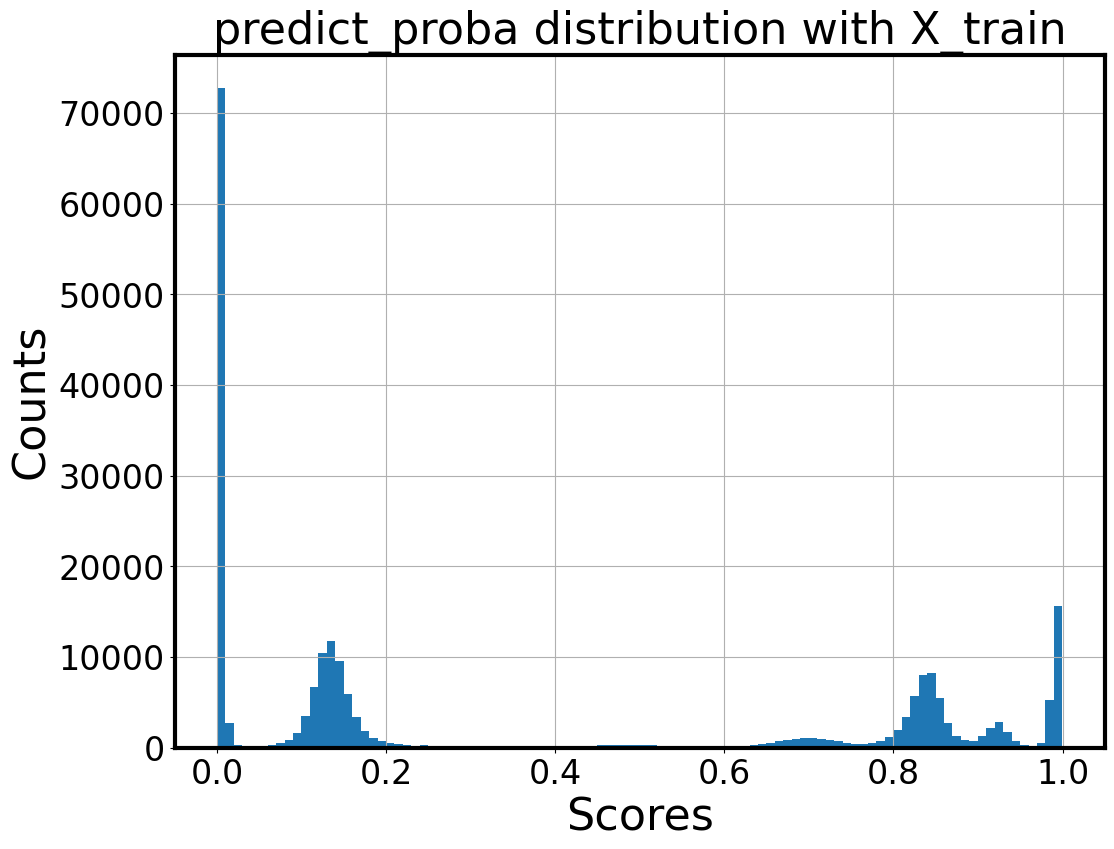

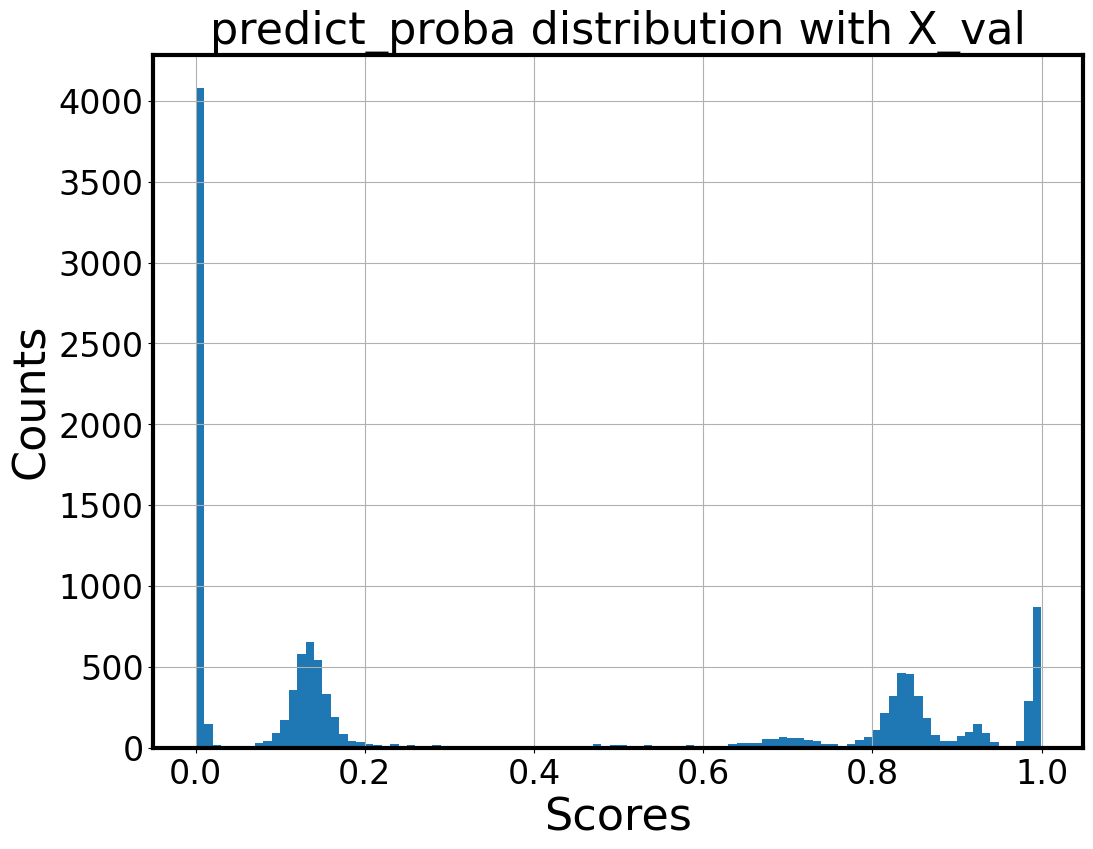

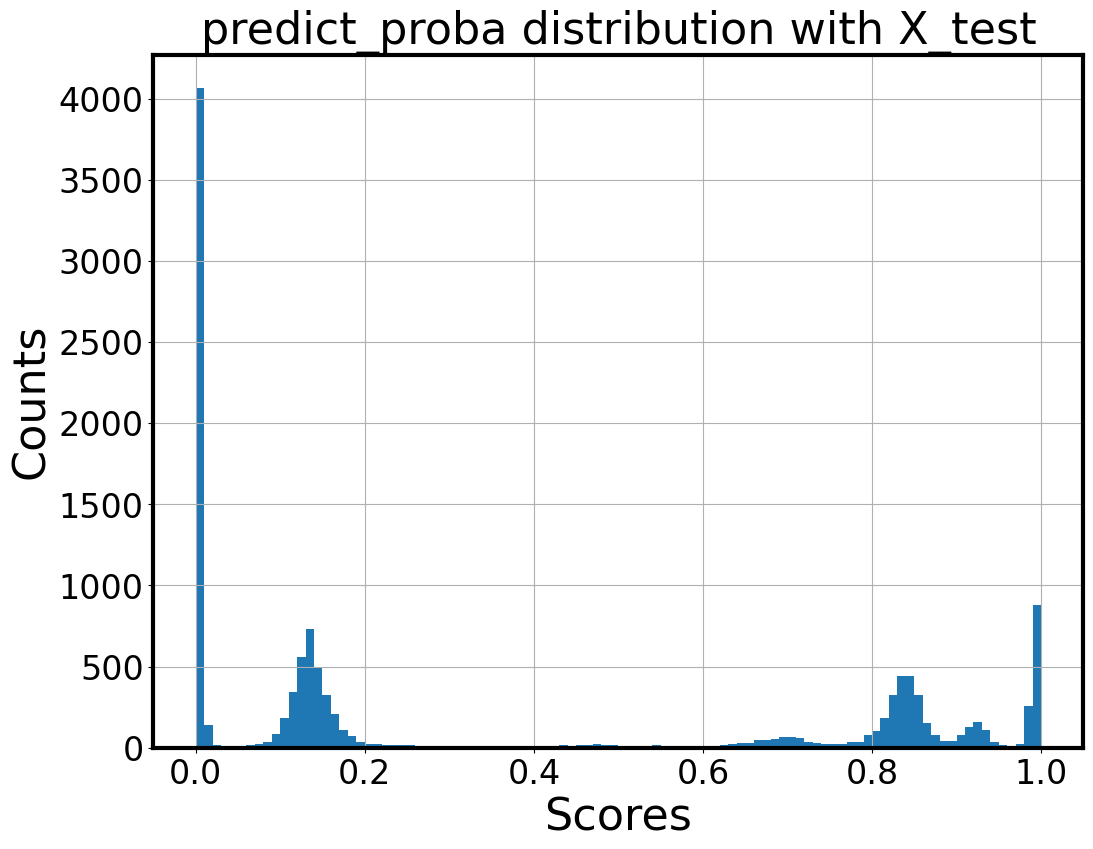

/Users/ddi/python_venv/pros/lib/python3.10/site-packages/kds/metrics.py:85: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dt = df.groupby('decile').apply(lambda x: pd.Series([


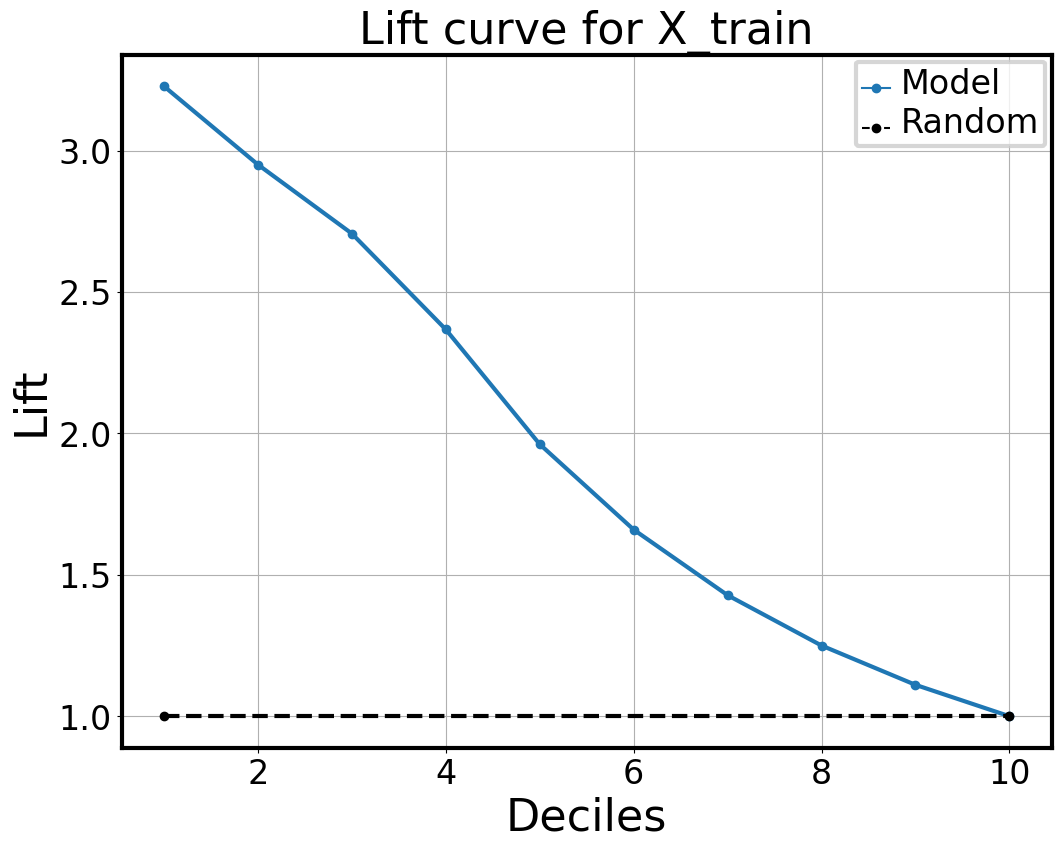

/Users/ddi/python_venv/pros/lib/python3.10/site-packages/kds/metrics.py:85: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dt = df.groupby('decile').apply(lambda x: pd.Series([


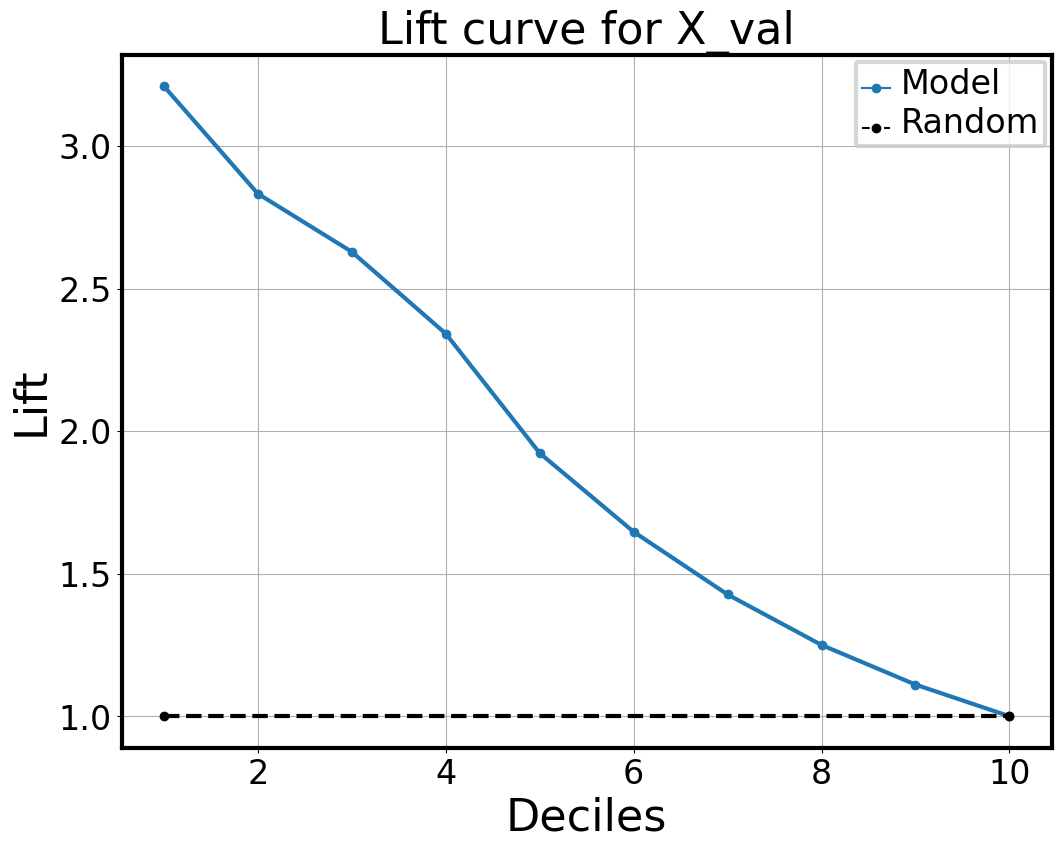

/Users/ddi/python_venv/pros/lib/python3.10/site-packages/kds/metrics.py:85: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dt = df.groupby('decile').apply(lambda x: pd.Series([


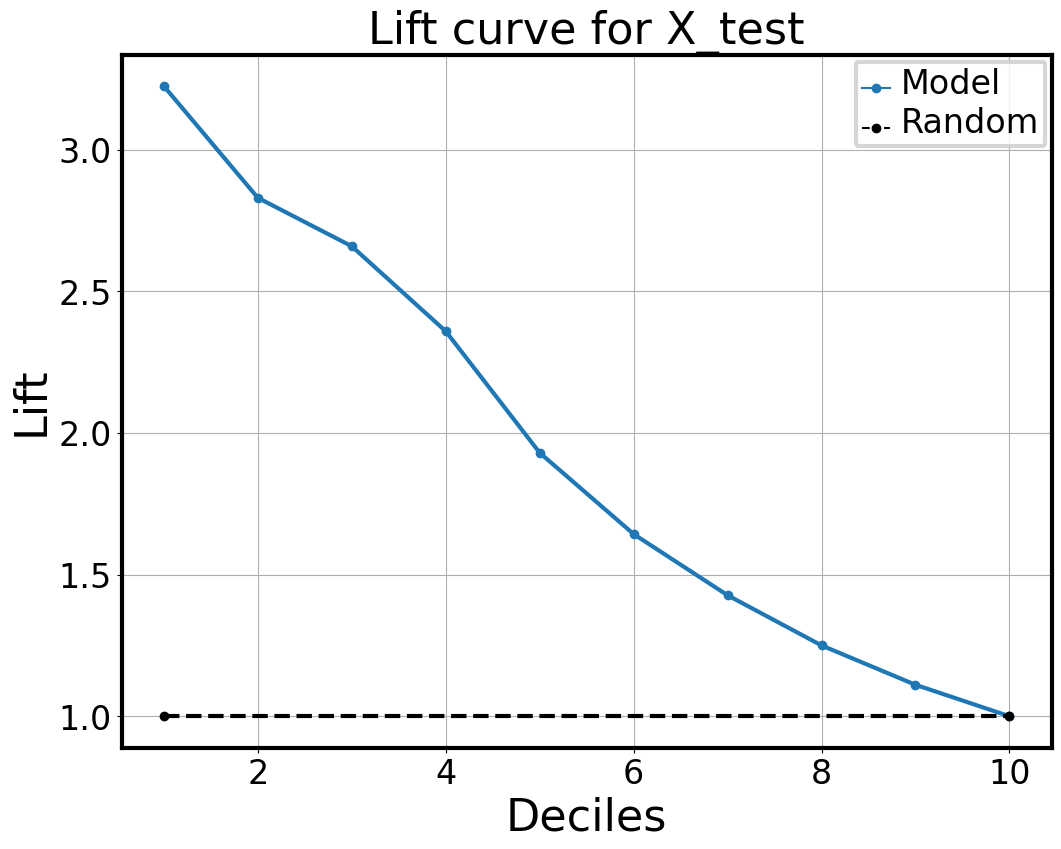



Classification report for X_train:


              precision    recall  f1-score   support

           0       0.97      0.87      0.92    156161
           1       0.76      0.93      0.84     68839

    accuracy                           0.89    225000
   macro avg       0.86      0.90      0.88    225000
weighted avg       0.90      0.89      0.89    225000


Classification report for X_val:


              precision    recall  f1-score   support

           0       0.96      0.86      0.91      8675
           1       0.75      0.92      0.83      3825

    accuracy                           0.88     12500
   macro avg       0.85      0.89      0.87     12500
weighted avg       0.90      0.88      0.88     12500


Classification report for X_test:


              precision    recall  f1-score   support

           0       0.96      0.87      0.91      8676
           1       0.76      0.92      0.83      3824

    accuracy                           0.89     12500
   macro avg    

<Figure size 2000x2000 with 0 Axes>

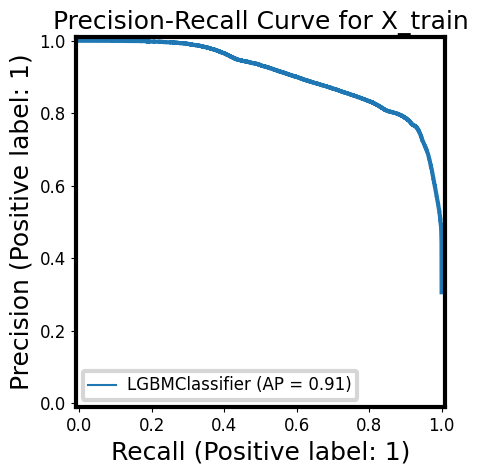

<Figure size 2000x2000 with 0 Axes>

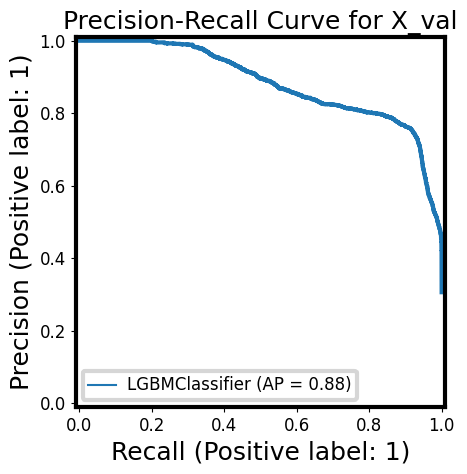

<Figure size 2000x2000 with 0 Axes>

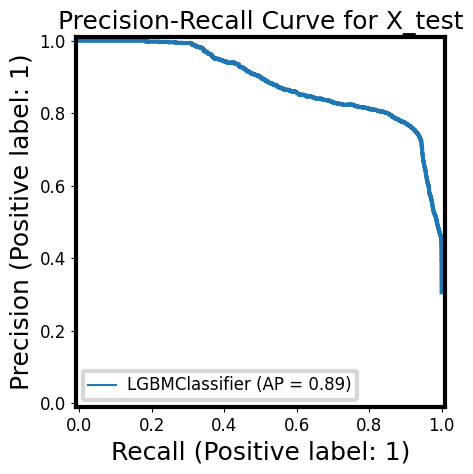

<Figure size 2000x2000 with 0 Axes>

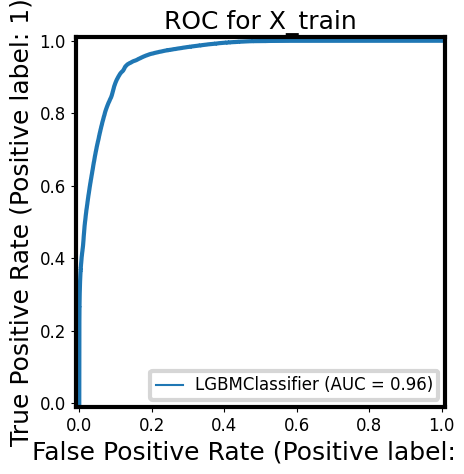

<Figure size 2000x2000 with 0 Axes>

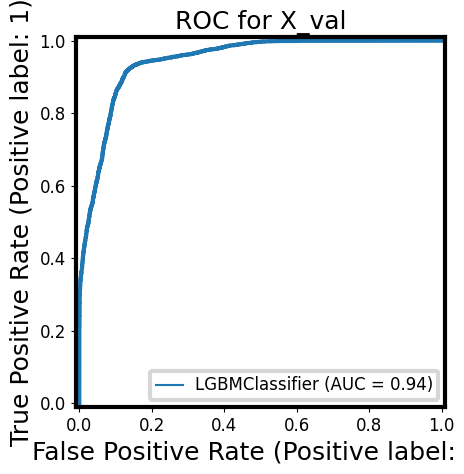

<Figure size 2000x2000 with 0 Axes>

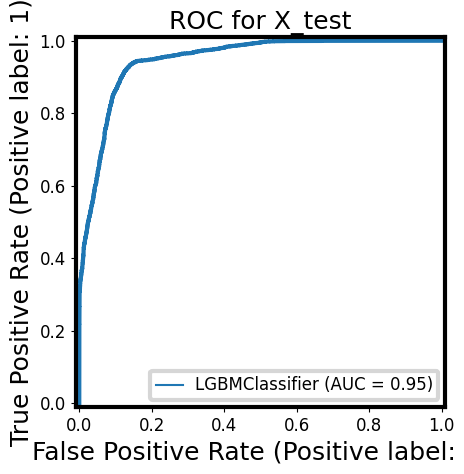


[[136018  20143]
 [  4765  64074]]
[[0.87101133 0.12898867]
 [0.06921948 0.93078052]]


<Figure size 2000x2000 with 0 Axes>

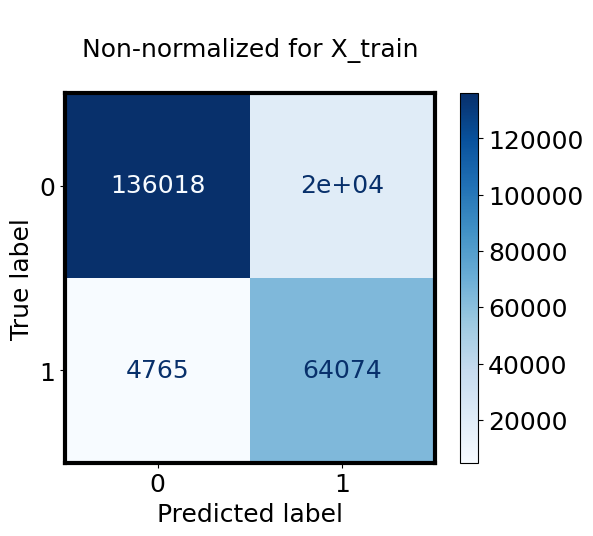

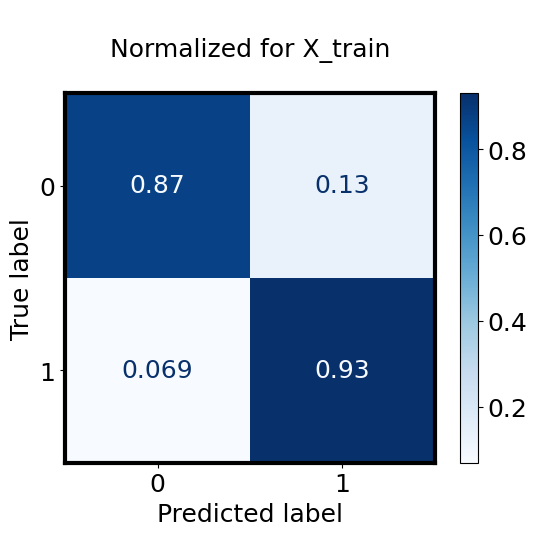

[[7483 1192]
 [ 301 3524]]
[[0.86259366 0.13740634]
 [0.07869281 0.92130719]]


<Figure size 2000x2000 with 0 Axes>

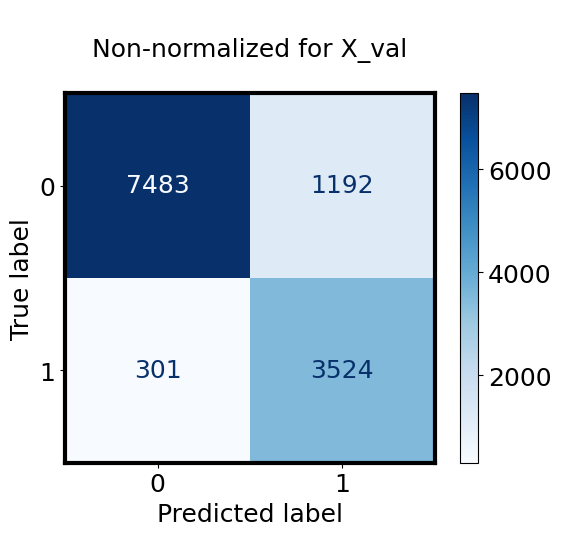

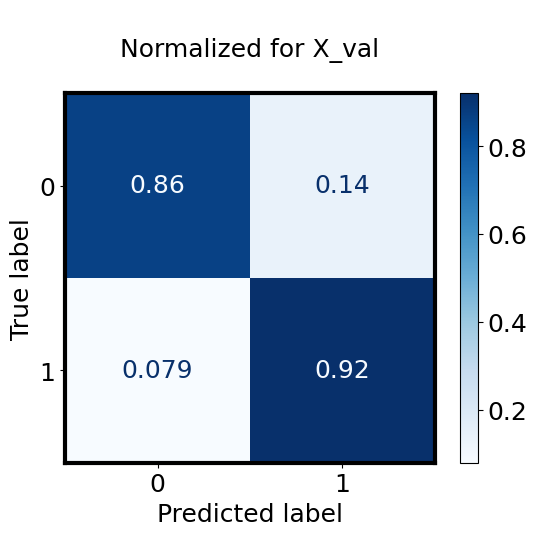

[[7540 1136]
 [ 298 3526]]
[[0.86906408 0.13093592]
 [0.07792887 0.92207113]]


<Figure size 2000x2000 with 0 Axes>

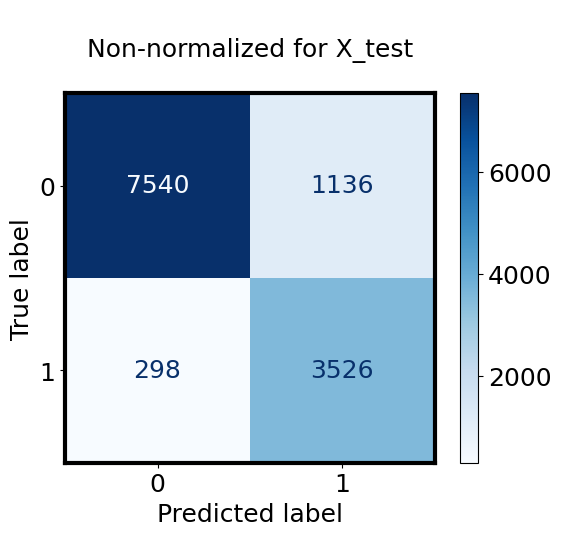

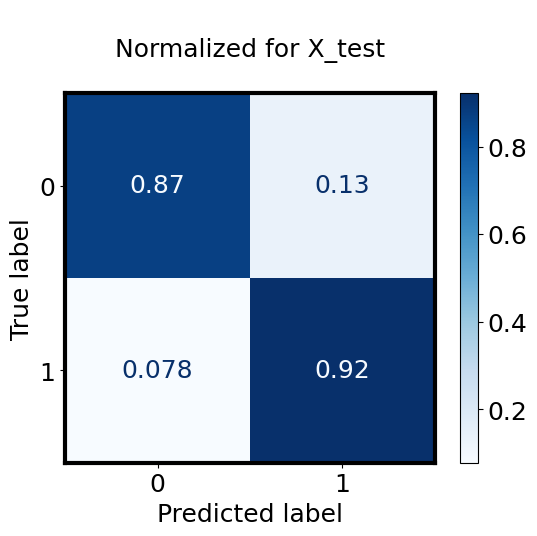



Shap plots with X_test:




 98%|===================| 12261/12500 [00:30<00:00]        

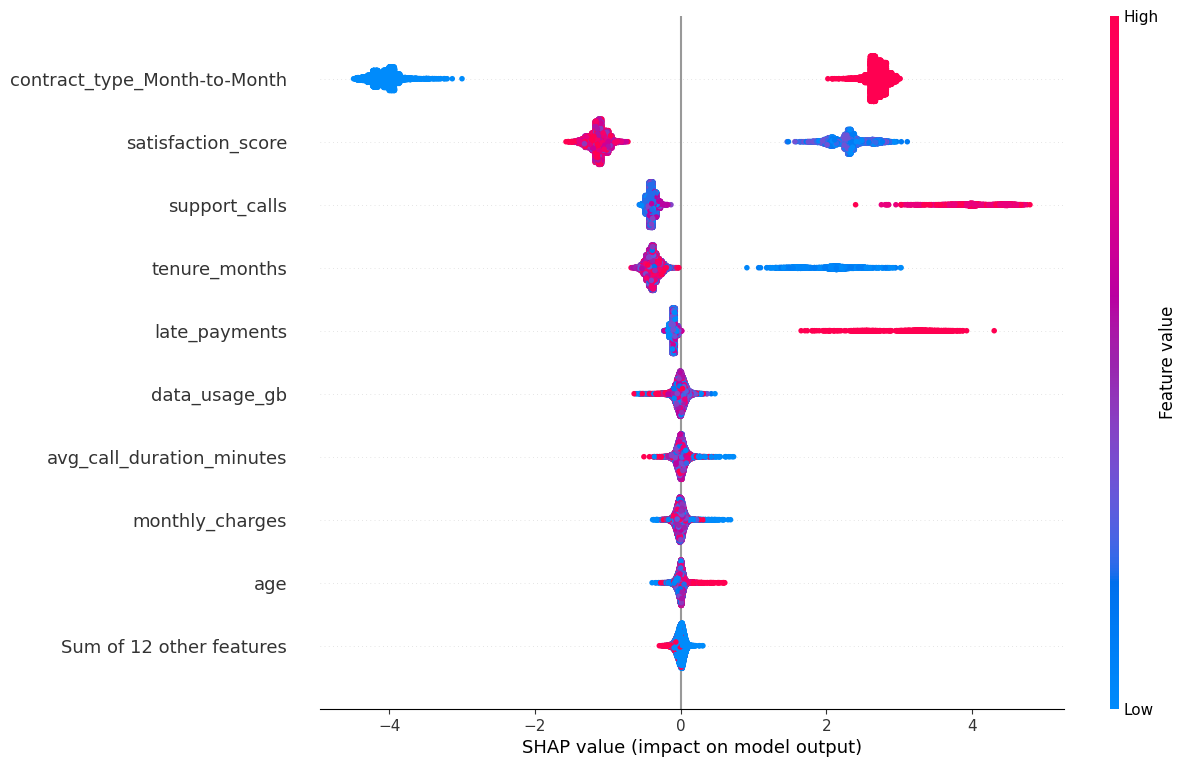

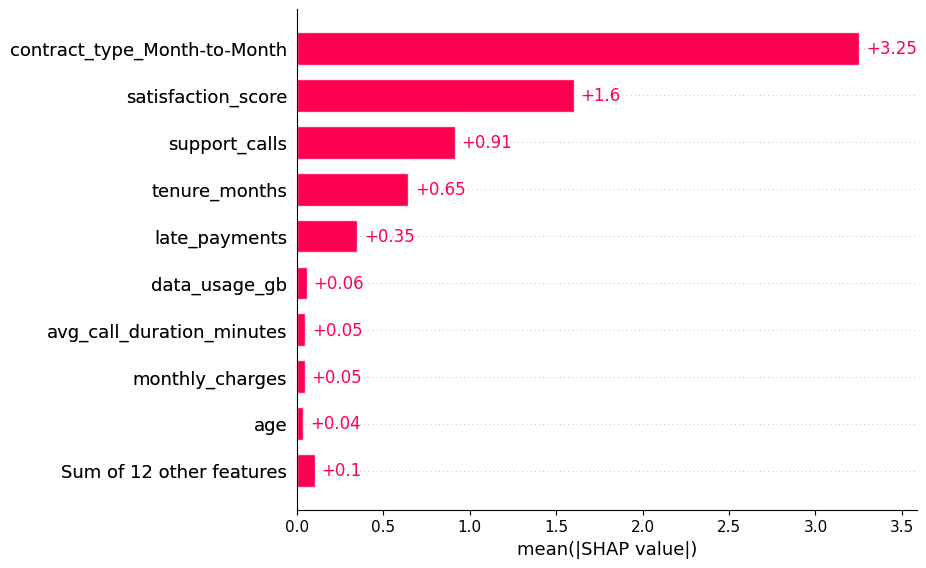

In [12]:
print("")
model_metrics.plot_probas()

print("")
model_metrics.plot_lift_curve()

print("")
model_metrics.print_classification_report()

print("")
model_metrics.plot_precision_recall_curve()

print("")
model_metrics.plot_roc()

print("")
model_metrics.plot_confusion_matrices()

print("")
model_metrics.plot_shap()